## Análisis exploratorio de los datos, visualizaciones y detección de patrones.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import importlib
import sys 
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
sys.path.append(os.path.abspath(".."))

In [ ]:
# Lectura de la data (csv)
ruta = "../data/winequality-white.csv"
# Añadimos sep=';' para que reconozca las columnas
df = pd.read_csv(ruta, sep=';')
# Verificación
print(f"Columnas detectadas: {df.columns.tolist()}")
df.head()

Columnas detectadas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [2]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


C:\Users\aguir\AppData\Local\Temp\ipykernel_16412\3986237077.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', palette='viridis')


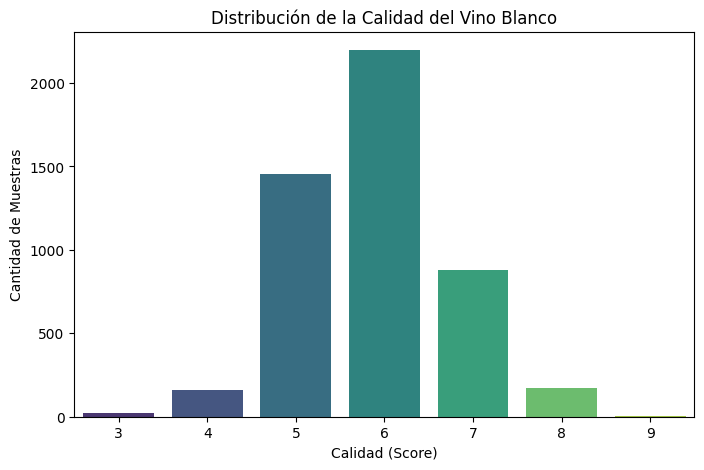

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='quality', palette='viridis')
plt.title('Distribución de la Calidad del Vino Blanco')
plt.xlabel('Calidad (Score)')
plt.ylabel('Cantidad de Muestras')
plt.show()

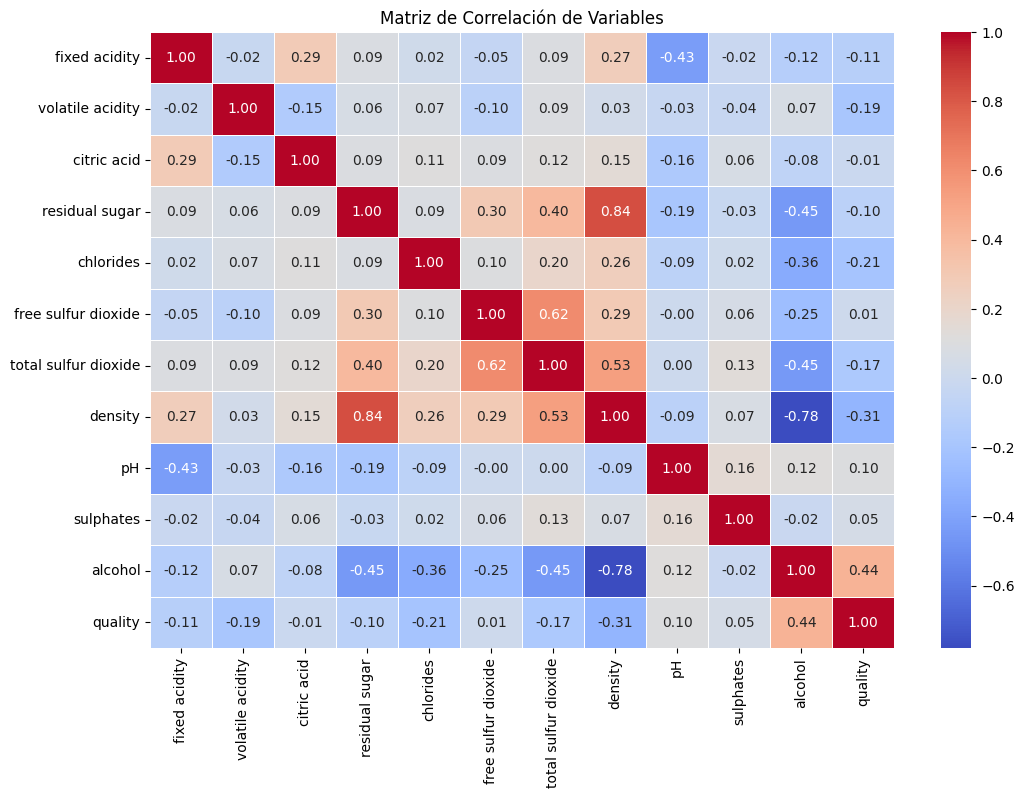

In [9]:
plt.figure(figsize=(12, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

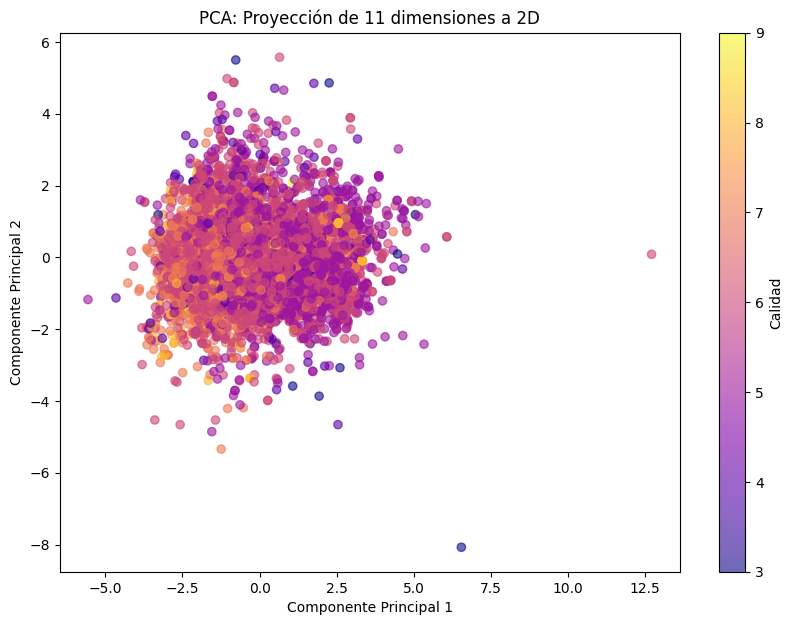

In [11]:
# Separamos las características (X) de la etiqueta (y)
X = df.drop('quality', axis=1)
y = df['quality']

# Estandarizamos (Media 0, Varianza 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos PCA a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Graficamos
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', alpha=0.6)
plt.colorbar(scatter, label='Calidad')
plt.title('PCA: Proyección de 11 dimensiones a 2D')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()